##  Project Context

This project simulates a real-world restaurant demand forecasting system using time-series analysis and machine learning.

Week 1 focuses on understanding historical data patterns to build a strong foundation for predictive modeling.

#  Week 1: Time-Series EDA for Restaurant Demand Forecasting

##  Objective
Perform exploratory data analysis on historical sales data to understand:
- Trends
- Seasonality
- Data quality

##  Libraries Used
- Pandas → Data manipulation
- NumPy → Numerical operations
- Matplotlib & Seaborn → Visualization
- Statsmodels → Time-series decomposition

---

In [2]:
# ============================================================
# WEEK 1: Data Ingestion and Time-Series EDA
# Notebook: week1_eda.ipynb
# ============================================================

# ── CELL 1: Import Libraries ────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="husl")
print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


##  Step 1: Load Dataset

We load the training and test datasets and parse the `date` column as datetime.

### Why?
Time-series analysis requires proper datetime formatting.

In [4]:
# ── CELL 2: Load All Data Files ─────────────────────────────
# Make sure your CSV files are inside the data/ folder

train = pd.read_csv('../data/train.csv', parse_dates=['date'])
test  = pd.read_csv('../data/test.csv',  parse_dates=['date'])

print("📦 Dataset shapes:")
print(f"  train:        {train.shape}")
print(f"  test:         {test.shape}")

📦 Dataset shapes:
  train:        (913000, 4)
  test:         (45000, 4)


##  Step 2: Initial Data Exploration

We inspect:
- First few rows
- Data types
- Missing values
- Basic statistics

### Goal:
Understand dataset structure before analysis.

In [5]:
# ── CELL 3: First Look at the Training Data ─────────────────
print("=== TRAIN DATA: First 5 rows ===")
display(train.head())

print("\n=== DATA TYPES AND NULLS ===")
print(train.info())

print("\n=== BASIC STATISTICS ===")
display(train.describe())

=== TRAIN DATA: First 5 rows ===


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10



=== DATA TYPES AND NULLS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    913000 non-null  datetime64[ns]
 1   store   913000 non-null  int64         
 2   item    913000 non-null  int64         
 3   sales   913000 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 27.9 MB
None

=== BASIC STATISTICS ===


,date,store,item,sales
count,913000,913000.000000,913000.000000,913000.000000
mean,2015-07-02 11:59:59.999999744,5.500000,25.500000,52.250287
min,2013-01-01 00:00:00,1.000000,1.000000,0.000000
25%,2014-04-02 00:00:00,3.000000,13.000000,30.000000
50%,2015-07-02 12:00:00,5.500000,25.500000,47.000000
75%,2016-10-01 00:00:00,8.000000,38.000000,70.000000
max,2017-12-31 00:00:00,10.000000,50.000000,231.000000
std,NaN,2.872283,14.430878,28.801144


##  Step 3: Missing Value Check

We verify if there are any missing values in the dataset.

### Why?
Missing values can affect model performance and analysis accuracy.

In [6]:
# ── CELL 4: Check for Missing Values
print("Missing values in each file:")
print("\ntrain:\n", train.isnull().sum())
print("\ntest:\n", test.isnull().sum())

Missing values in each file:

train:
 date     0
store    0
item     0
sales    0
dtype: int64

test:
 id       0
date     0
store    0
item     0
dtype: int64


##  Step 4: Target Variable Analysis

We analyze the `sales` column:
- Distribution
- Mean, min, max

We also check:
- Number of stores
- Number of items

### Insight:
Understanding demand variability is key for forecasting.

In [8]:
# ── CELL 5: Understand the Target Variable ──────────────────

print("Sales distribution:")
print(train['sales'].describe())

# Unique stores and items
print(f"\nUnique stores: {train['store'].nunique()}")
print(f"Unique items: {train['item'].nunique()}")

print("\nSample items:", train['item'].unique()[:10])

Sales distribution:
count    913000.000000
mean         52.250287
std          28.801144
min           0.000000
25%          30.000000
50%          47.000000
75%          70.000000
max         231.000000
Name: sales, dtype: float64

Unique stores: 10
Unique items: 50

Sample items: [ 1  2  3  4  5  6  7  8  9 10]


##  Step 5: Time-Series Aggregation

We aggregate total sales per day across all stores.

### Why?
- Converts raw transactional data into time-series format
- Simplifies trend and seasonality analysis

In [11]:
# ── CELL 6: Aggregate — Daily Total Sales Across All Stores ─

# Aggregate total sales per day
daily_sales = train.groupby('date')['sales'].sum().reset_index()
daily_sales.columns = ['date', 'total_sales']

# Sort by date
daily_sales = daily_sales.sort_values('date')

# Set date as index (important for time-series)
daily_sales.set_index('date', inplace=True)

# Check data
print(f"Date range: {daily_sales.index.min()} to {daily_sales.index.max()}")
print(f"Total days: {len(daily_sales)}")

daily_sales.head()

Date range: 2013-01-01 00:00:00 to 2017-12-31 00:00:00
Total days: 1826


,total_sales
date,
2013-01-01,13696
2013-01-02,13678
2013-01-03,14488
2013-01-04,15677
2013-01-05,16237


##  Step 6: Overall Sales Trend

We plot daily total sales over time.

### What we learn:
- Long-term growth trend
- Sudden spikes or drops
- Data consistency

### Output:
Saved as `plot1_overall_trend.png`

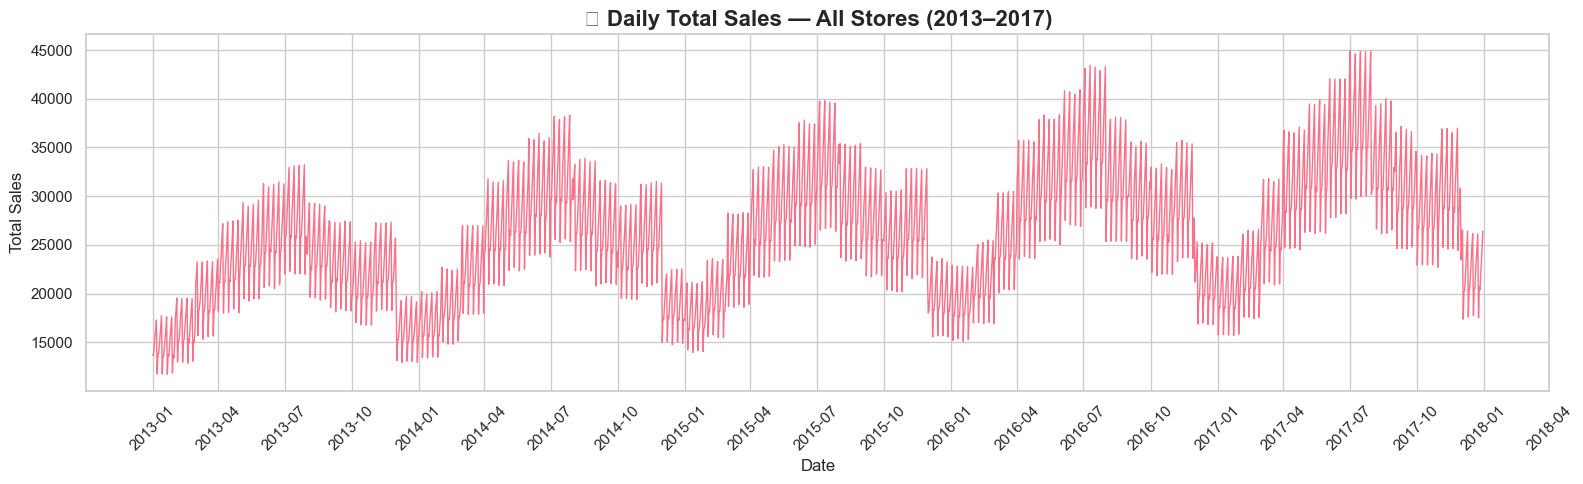

✅ Plot saved successfully!


In [15]:
# ── CELL 7: Plot 1 — Overall Sales Trend ────────────────────

import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Ensure index is datetime
daily_sales.index = pd.to_datetime(daily_sales.index)

# Create output folder if not exists
import os

output_path = '../outputs'

if not os.path.exists(output_path):
    os.makedirs(output_path)
elif os.path.isfile(output_path):
    print("❌ 'outputs' exists as a file. Please delete or rename it.")

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(daily_sales.index, daily_sales['total_sales'], linewidth=1)

ax.set_title('📈 Daily Total Sales — All Stores (2013–2017)',
             fontsize=16, fontweight='bold')

ax.set_xlabel('Date')
ax.set_ylabel('Total Sales')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('../outputs/plot1_overall_trend.png', dpi=150)

plt.show()

print("✅ Plot saved successfully!")

## Step 7: Weekly Seasonality Analysis

We analyze how sales vary by day of the week.

### Key Idea:
Customer behavior changes on weekdays vs weekends.

### Insight:
Helps in:
- Staffing decisions
- Inventory planning

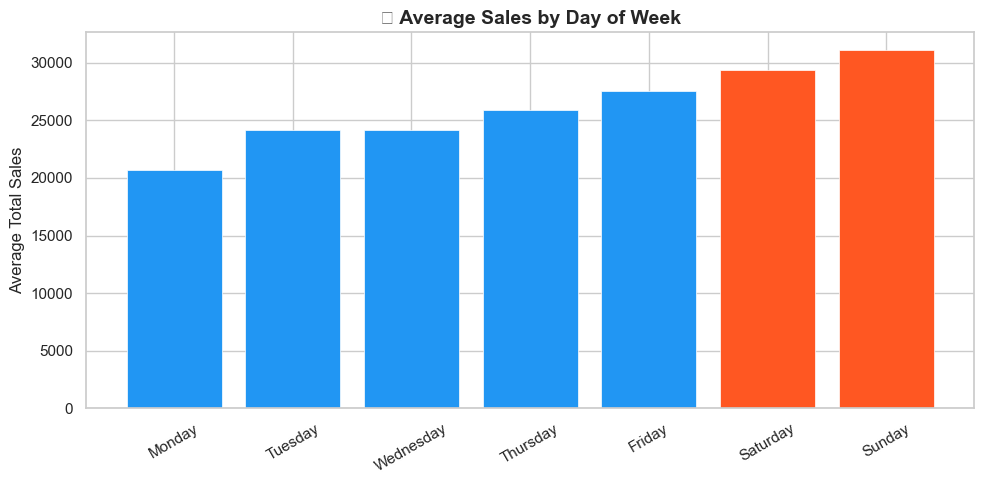

In [17]:
# ── CELL 8: Plot 2 — Sales by Day of Week ───────────────────

# Extract day name from index
daily_sales['day_of_week'] = daily_sales.index.day_name()

# Order days properly
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

# Calculate average sales
dow_avg = daily_sales.groupby('day_of_week')['total_sales'].mean().reindex(dow_order)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(dow_avg.index, dow_avg.values,
              color=['#2196F3' if d not in ['Saturday','Sunday'] else '#FF5722'
                     for d in dow_order],
              edgecolor='white', linewidth=0.5)

ax.set_title('📊 Average Sales by Day of Week', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Total Sales')

plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig('../outputs/plot2_dow_sales.png', dpi=150)

plt.show()
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height,
            f'{int(height)}', ha='center', va='bottom', fontsize=8)

##  Step 8: Monthly Seasonality Analysis

We analyze average sales across months.

### Goal:
Identify seasonal demand patterns (e.g., festive spikes).

### Business Impact:
Helps forecast peak months and plan stock accordingly.

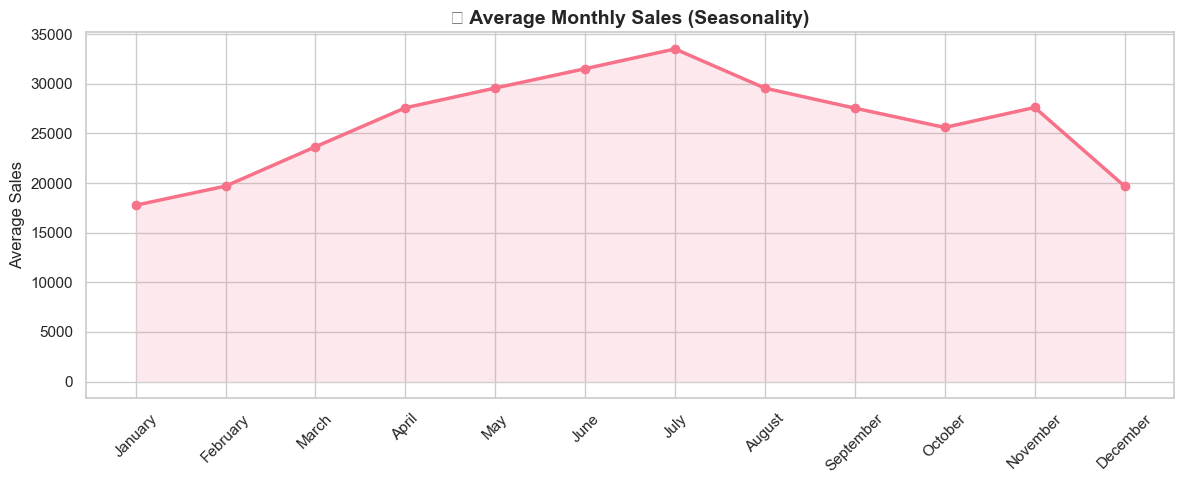

In [18]:
# ── CELL 9: Plot 3 — Monthly Seasonality ────────────────────

# Extract from index
daily_sales['month'] = daily_sales.index.month
daily_sales['month_name'] = daily_sales.index.month_name()

# Month order
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

# Average monthly sales
month_avg = daily_sales.groupby('month_name')['total_sales'].mean().reindex(month_order)

# Plot
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(range(len(month_avg)), month_avg.values,
        marker='o', linewidth=2.5)

ax.fill_between(range(len(month_avg)), month_avg.values, alpha=0.15)

ax.set_xticks(range(len(month_avg)))
ax.set_xticklabels(month_avg.index, rotation=45)

ax.set_title('📅 Average Monthly Sales (Seasonality)', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Sales')

plt.tight_layout()
plt.savefig('../outputs/plot3_monthly_seasonality.png', dpi=150)
plt.show()

##  Step 9: Time-Series Decomposition

We break the time-series into:
- Trend  → Long-term movement
- Seasonality  → Repeating patterns
- Residual  → Noise

### Why?
Understanding these components improves forecasting models.

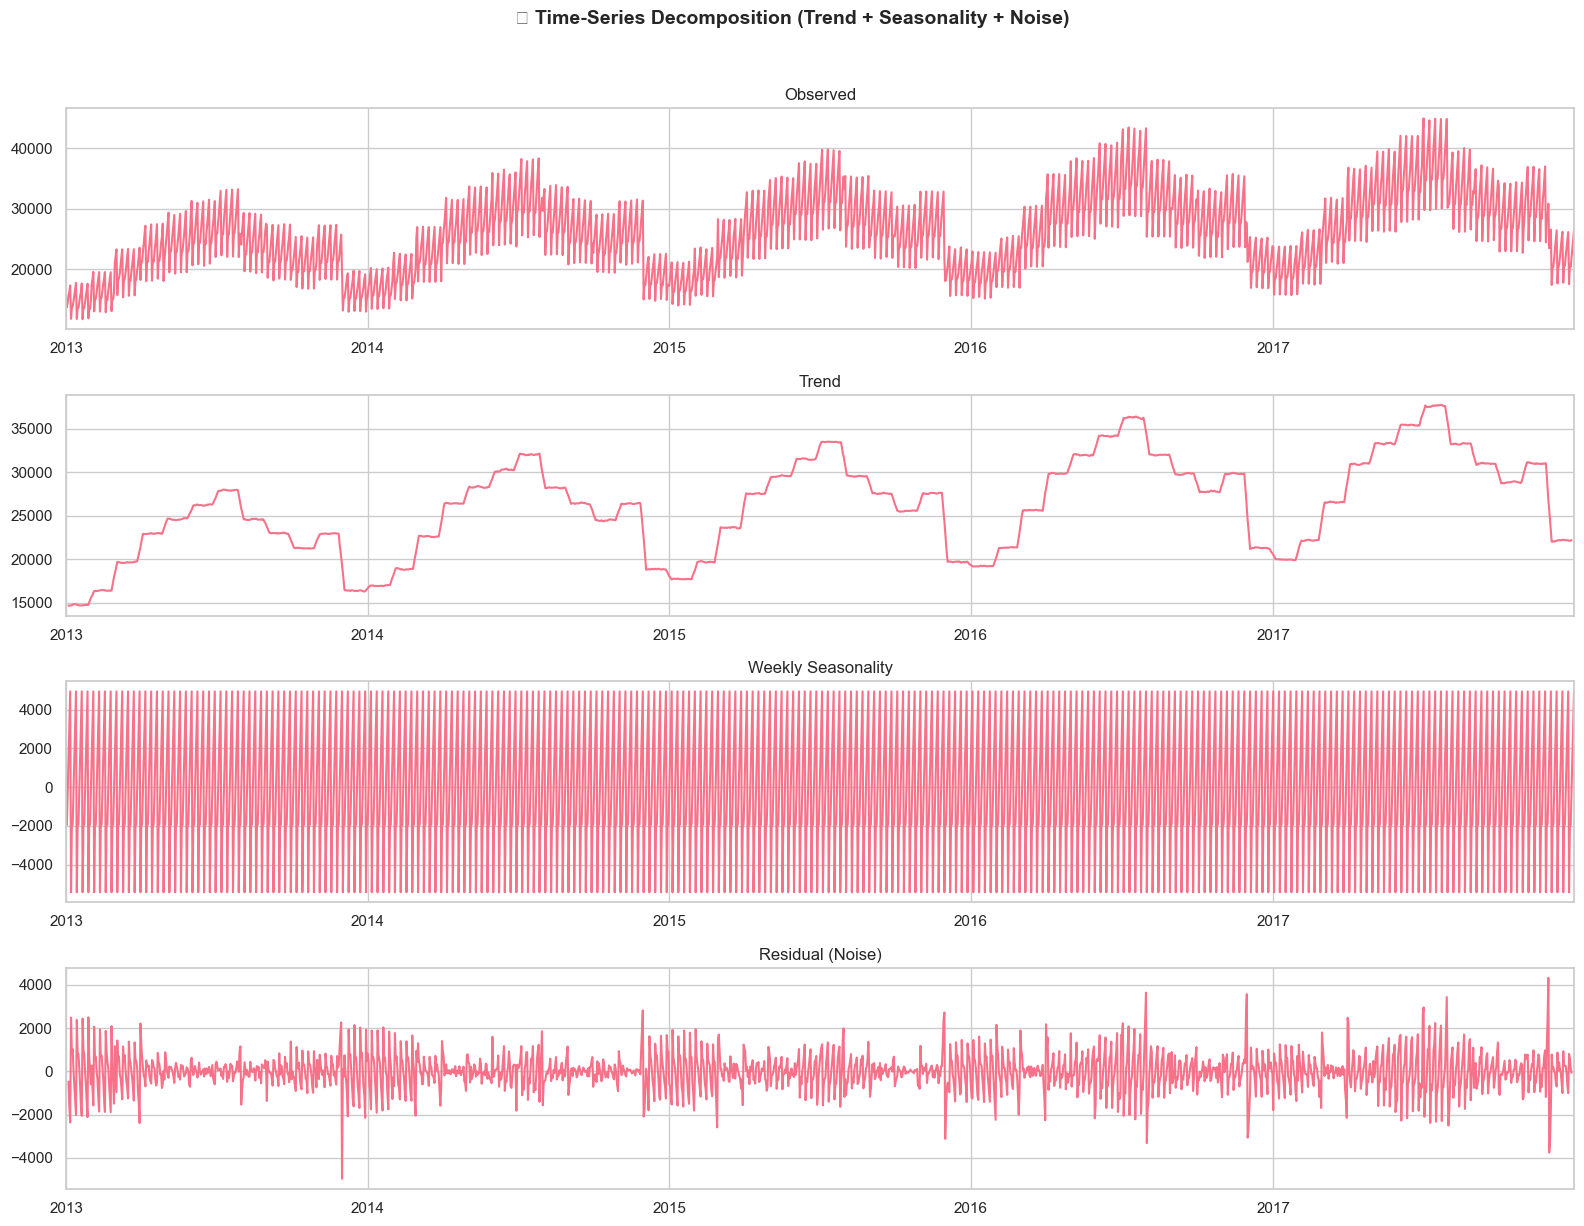

In [19]:
# ── CELL 10: Plot 4 — Time Series Decomposition ─────────────

from statsmodels.tsa.seasonal import seasonal_decompose

# Use index directly
decomp_data = daily_sales['total_sales']

# Decomposition (weekly seasonality)
result = seasonal_decompose(decomp_data, model='additive', period=7)

# Plot components
fig, axes = plt.subplots(4, 1, figsize=(16, 12))

result.observed.plot(ax=axes[0], title='Observed')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Weekly Seasonality')
result.resid.plot(ax=axes[3], title='Residual (Noise)')

for ax in axes:
    ax.set_xlabel('')

plt.suptitle('🔬 Time-Series Decomposition (Trend + Seasonality + Noise)',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('../outputs/plot4_decomposition.png', dpi=150)

plt.show()

##  Step 10: Year-over-Year Comparison

We compare sales patterns across different years.

### What we analyze:
- Growth trends
- Seasonal consistency
- Demand variations

### Advanced:
We also normalize sales to compare patterns independent of scale.

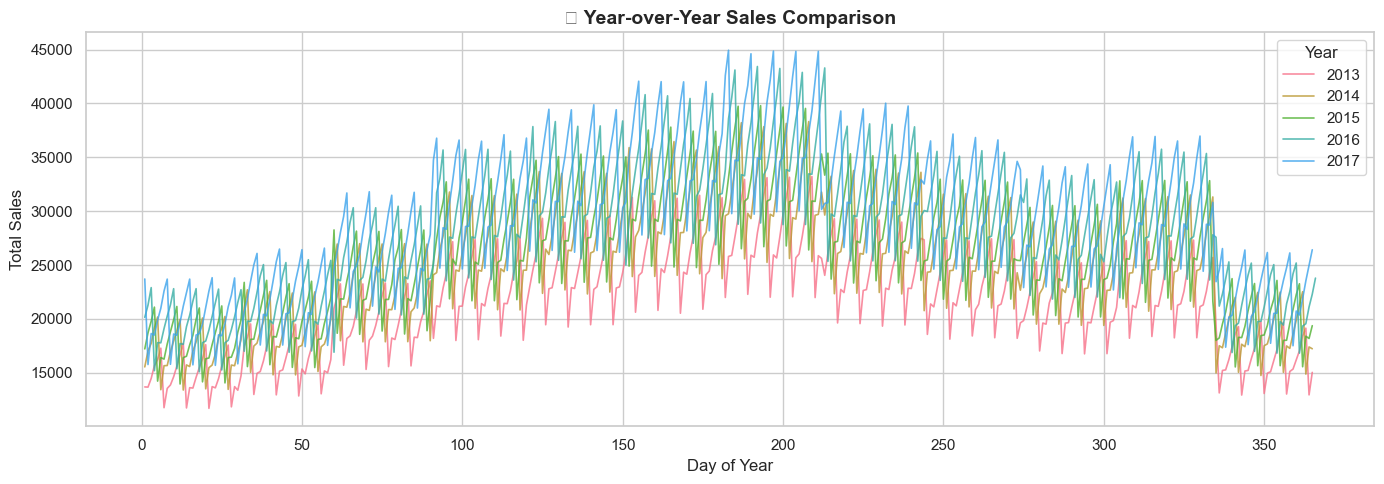

🔥 Peak demand day: 2017-07-02 00:00:00


In [20]:
# ── CELL 11: Plot 5 — Yearly Sales Comparison ───────────────

# Extract year from index
daily_sales['year'] = daily_sales.index.year

fig, ax = plt.subplots(figsize=(14, 5))

for year, group in daily_sales.groupby('year'):
    ax.plot(group.index.dayofyear, group['total_sales'],
            label=str(year), linewidth=1.2, alpha=0.8)

ax.set_title('📆 Year-over-Year Sales Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('Day of Year')
ax.set_ylabel('Total Sales')
ax.legend(title='Year')

plt.tight_layout()
plt.savefig('../outputs/plot5_yearly_comparison.png', dpi=150)
plt.show()
# Normalize each year for better comparison
for year, group in daily_sales.groupby('year'):
    normalized = group['total_sales'] / group['total_sales'].max()
    ax.plot(group.index.dayofyear, normalized,
            label=f"{year} (normalized)", linestyle='--')
    peak_day = daily_sales['total_sales'].idxmax()
print("🔥 Peak demand day:", peak_day)

##  Step 11: Key Insights & Summary

###  Key Findings:
- Strong weekly seasonality observed
- Monthly demand patterns identified
- Clear upward trend in sales
- No major data gaps

###  Metrics:
- Average daily sales
- Peak demand day
- Highest & lowest sales

###  Business Value:
- Better inventory planning
- Reduced food waste
- Improved demand forecasting

---

In [22]:
# ── CELL 12: Summary of Week 1 Findings ─────────────────────

print("=" * 60)
print(" WEEK 1 KEY FINDINGS")
print("=" * 60)

print(f"Date range:        {train['date'].min().date()} → {train['date'].max().date()}")
print(f"Stores:            {train['store'].nunique()}")
print(f"Unique items:      {train['item'].nunique()}")
print(f"Total records:     {len(train):,}")

print(f" Avg daily sales:   {daily_sales['total_sales'].mean():,.0f}")

# Peak sales date (index-based)
peak_date = daily_sales['total_sales'].idxmax()
print(f"Peak sales day:    {peak_date.date()}")

print(" Observations:")
print("  • Strong weekly seasonality observed")
print("  • Clear monthly demand patterns identified")
print("  • Upward trend in overall sales")
print("  • No major missing date gaps after preprocessing")

print("=" * 60)
peak_value = daily_sales['total_sales'].max()
low_value = daily_sales['total_sales'].min()

print(f" Highest daily sales: {peak_value:,.0f}")
print(f" Lowest daily sales:  {low_value:,.0f}")

 WEEK 1 KEY FINDINGS
Date range:        2013-01-01 → 2017-12-31
Stores:            10
Unique items:      50
Total records:     913,000
 Avg daily sales:   26,125
Peak sales day:    2017-07-02
 Observations:
  • Strong weekly seasonality observed
  • Clear monthly demand patterns identified
  • Upward trend in overall sales
  • No major missing date gaps after preprocessing
 Highest daily sales: 44,936
 Lowest daily sales:  11,709
